### Load relevant libraries

In [20]:
import os
import pandas as pd
pd.set_option('display.max_columns', None)

import numpy as np

import seaborn as sns
import matplotlib.pyplot as plt

import scipy.cluster.hierarchy as sch
import networkx as nx

### Read in the data

In [21]:
# Set working directory (necessary until 2019 data comes out)
path = 'C:/Users/caanm/OneDrive/Documents/Project Portfolio/March Madness 2026/2026 Data'
os.chdir(path)

In [22]:
# Read in datasets
df = pd.read_csv('df_full.csv', sep=',', index_col=None)

### Summary descriptions

In [23]:
display(df.head(), df.shape)

,team,season,conf,z.efg,z.sa,z.pt,rank,top,mid,bot,z.winsbefore,z.winsafter,z.clutch,z.close,z.grit,z.has_ot,z.off,z.def,z.Ast,z.TO,z.Stl,z.Blk,z.OR,z.DR,z.3m,z.3a,winpercintourney,intourney,seed_strength,M_W,conf_strength
0,1101,2022,wac,-0.045659,0.341508,0.652882,8,0,0,1,0.763072,0.728473,0.489360,1.114148,-0.378251,1.101226,0.943241,0.202626,0.648655,-0.682630,2.193933,-1.412967,-0.094237,-1.595220,0.085824,0.260685,0.0,0.0,17.0,M,18.0
1,1102,2022,mwc,0.575808,-1.261292,-0.880197,13,0,0,1,0.158470,-1.266570,1.012846,0.012930,0.000000,-1.176542,-1.191500,-0.186385,-0.146769,-0.827191,-1.033984,-0.148112,-2.215604,-2.048607,0.384044,0.322057,0.0,0.0,17.0,M,25.0
2,1103,2022,mac,1.283811,-0.813785,0.701176,4,0,1,0,1.169411,1.095981,0.489360,0.877327,-1.182384,-0.463301,0.357069,-0.492648,-0.631498,-1.169474,-1.031829,-0.087983,-0.581809,0.131697,0.715933,0.354015,0.0,1.0,4.0,M,14.0
3,1104,2022,sec,0.400822,2.566417,0.496933,7,0,1,0,1.138905,0.728473,0.413018,1.435336,-1.182384,-0.686189,1.969446,1.509372,0.927486,0.195126,-0.032216,1.477683,1.480216,0.756175,1.686757,2.493891,0.0,1.0,11.0,M,30.0
4,1105,2022,swac,-1.364236,-1.079965,-0.693320,13,0,0,1,-1.088031,1.300152,0.031310,1.701464,1.230014,-0.417286,-0.829288,-0.028526,-1.642512,-0.165584,-0.010697,0.011659,0.312990,0.358990,-1.637459,-1.504765,0.0,0.0,17.0,M,1.0


(3614, 31)

In [24]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3614 entries, 0 to 3613
Data columns (total 31 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   team              3614 non-null   int64  
 1   season            3614 non-null   int64  
 2   conf              3614 non-null   object 
 3   z.efg             3614 non-null   float64
 4   z.sa              3614 non-null   float64
 5   z.pt              3614 non-null   float64
 6   rank              3614 non-null   int64  
 7   top               3614 non-null   int64  
 8   mid               3614 non-null   int64  
 9   bot               3614 non-null   int64  
 10  z.winsbefore      3614 non-null   float64
 11  z.winsafter       3614 non-null   float64
 12  z.clutch          3614 non-null   float64
 13  z.close           3614 non-null   float64
 14  z.grit            3614 non-null   float64
 15  z.has_ot          3614 non-null   float64
 16  z.off             3614 non-null   float64


In [25]:
#Check main statistics of variables
df.describe()

,team,season,z.efg,z.sa,z.pt,rank,top,mid,bot,z.winsbefore,z.winsafter,z.clutch,z.close,z.grit,z.has_ot,z.off,z.def,z.Ast,z.TO,z.Stl,z.Blk,z.OR,z.DR,z.3m,z.3a,winpercintourney,intourney,seed_strength,conf_strength
count,3614.000000,3614.000000,3.614000e+03,3.614000e+03,3.614000e+03,3614.000000,3614.000000,3614.000000,3614.000000,3.614000e+03,3.614000e+03,3.614000e+03,3.614000e+03,3.614000e+03,3.614000e+03,3.614000e+03,3.614000e+03,3.614000e+03,3.614000e+03,3.614000e+03,3.614000e+03,3.614000e+03,3.614000e+03,3.614000e+03,3.614000e+03,3614.000000,3614.000000,3614.000000,3614.000000
mean,2287.795241,2024.008301,1.494224e-16,8.454161e-16,-1.228802e-17,11.066132,0.139734,0.197565,0.662701,-2.457605e-18,4.177928e-17,-1.071516e-16,7.864336e-17,-3.268615e-17,1.022364e-16,-5.662322e-16,-3.460308e-16,-2.482181e-16,-9.437203e-17,3.145734e-17,3.578273e-16,-1.808797e-16,-2.978617e-16,7.077902e-17,7.077902e-17,0.047722,0.150526,15.345600,17.546763
std,1005.933771,1.413406,9.994463e-01,9.994463e-01,9.994463e-01,6.433874,0.346759,0.398217,0.472853,9.994463e-01,9.991693e-01,9.984766e-01,9.994463e-01,8.797000e-01,9.994463e-01,9.994463e-01,9.994463e-01,9.994463e-01,9.994463e-01,9.994463e-01,9.994463e-01,9.994463e-01,9.994463e-01,9.994463e-01,9.994463e-01,0.167801,0.357635,3.988336,9.255090
min,1101.000000,2022.000000,-4.067767e+00,-3.767596e+00,-3.965253e+00,1.000000,0.000000,0.000000,0.000000,-2.389967e+00,-1.976930e+00,-2.428288e+00,-2.635682e+00,-1.275128e+00,-1.205681e+00,-3.309308e+00,-3.222565e+00,-3.049082e+00,-2.452699e+00,-2.596440e+00,-2.309857e+00,-3.399493e+00,-3.522832e+00,-3.838422e+00,-4.287816e+00,0.000000,0.000000,1.000000,1.000000
25%,1290.000000,2023.000000,-6.880653e-01,-6.572668e-01,-6.296321e-01,6.000000,0.000000,0.000000,0.000000,-7.439698e-01,-7.409302e-01,-7.300444e-01,-6.942969e-01,-6.999040e-01,-6.636983e-01,-6.866563e-01,-7.106749e-01,-7.040840e-01,-7.833413e-01,-6.877721e-01,-6.962158e-01,-6.692498e-01,-6.760980e-01,-7.056391e-01,-6.762527e-01,0.000000,0.000000,17.000000,10.000000
50%,1478.500000,2024.000000,8.599705e-02,-2.060090e-02,-8.569461e-03,11.000000,0.000000,0.000000,1.000000,-3.154805e-02,-4.737662e-02,2.214232e-02,-3.654627e-02,0.000000e+00,-3.164333e-01,5.926152e-02,3.847125e-02,-9.413137e-02,-1.605276e-01,-1.232637e-01,-1.161123e-01,-4.989807e-02,-4.557010e-02,5.662905e-03,-1.151200e-03,0.000000,0.000000,17.000000,18.000000
75%,3290.000000,2025.000000,7.173283e-01,6.388661e-01,6.339930e-01,16.000000,0.000000,0.000000,1.000000,7.179228e-01,6.927020e-01,6.493490e-01,6.475258e-01,6.273927e-01,4.843089e-01,6.983246e-01,7.067779e-01,6.172909e-01,7.138634e-01,5.654098e-01,5.908291e-01,6.131695e-01,6.134657e-01,6.759516e-01,6.726461e-01,0.000000,0.000000,17.000000,26.000000
max,3481.000000,2026.000000,3.528542e+00,4.609181e+00,4.430293e+00,33.000000,1.000000,1.000000,1.000000,2.933083e+00,2.211598e+00,2.472573e+00,3.635433e+00,1.277276e+00,6.309915e+00,3.224583e+00,2.894203e+00,4.585045e+00,3.661786e+00,5.367200e+00,6.037959e+00,5.607577e+00,4.399705e+00,3.388302e+00,3.711607e+00,1.000000,1.000000,17.000000,33.000000


### Boxplots for Distribution

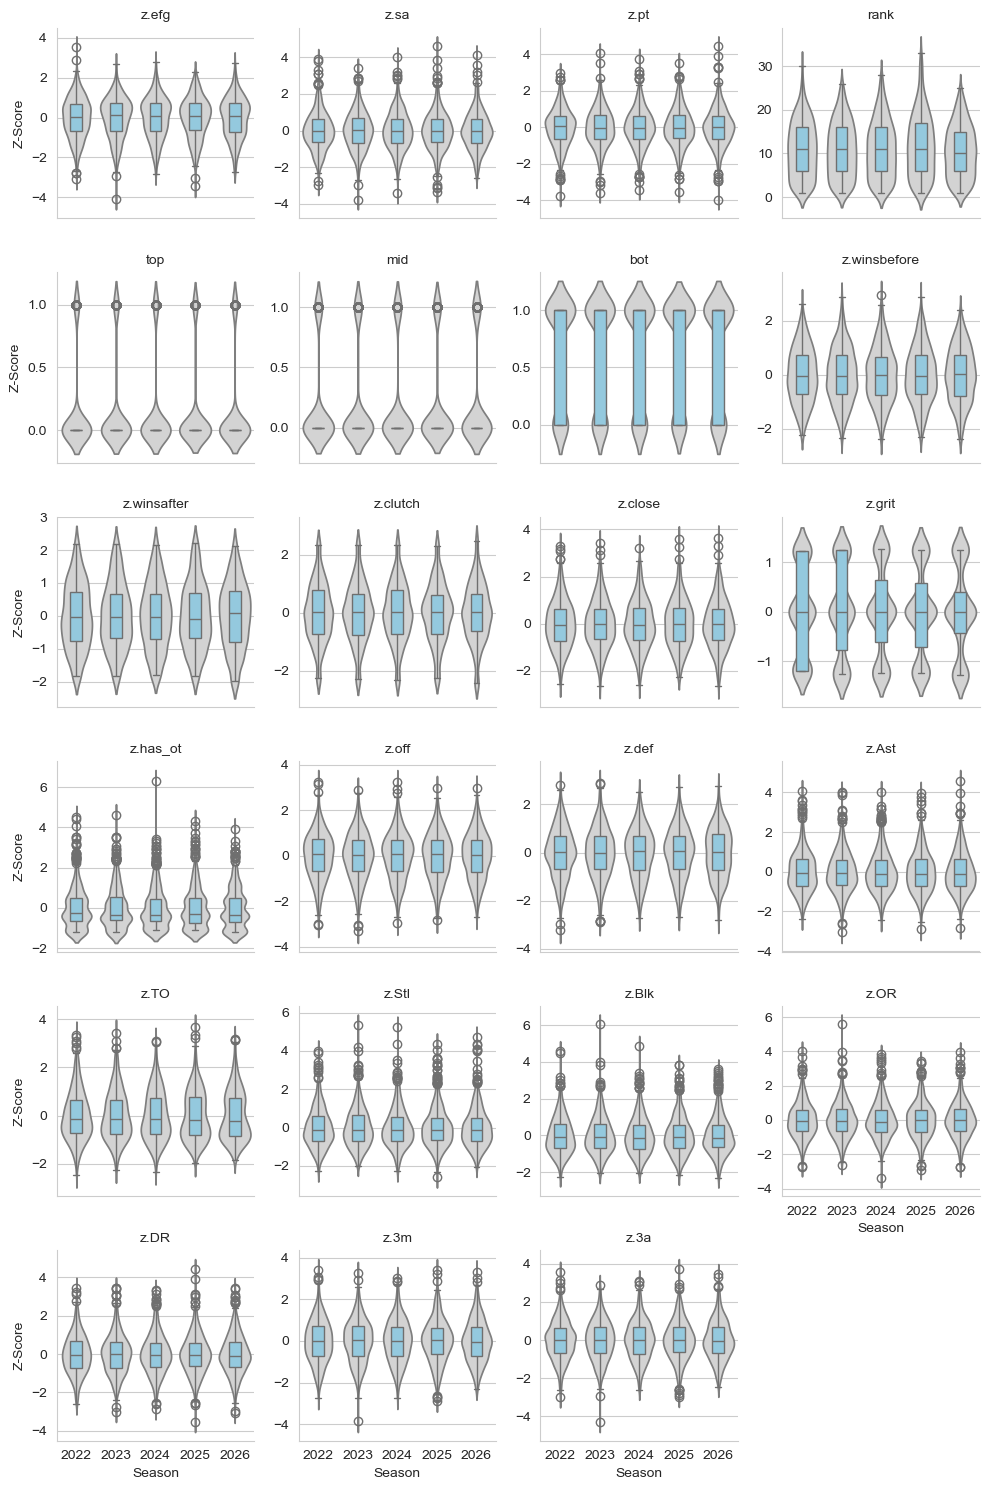

In [26]:
#Create and show boxplot for variables

df2 = df.melt(id_vars=['season', 'team', 'M_W'])

cols = list(df.loc[:, 'z.efg':'z.3a'])
season_order = sorted(df2['season'].unique())

# sort variables by variance
var_order = df[cols].std().sort_values(ascending=False).index.tolist()
facet_vars = var_order

sns.set_style('whitegrid')

grid = sns.FacetGrid(
    df2[df2.variable.isin(cols)],
    col='variable',
    col_wrap=4,
    sharey=False,
    height=2.5
)

grid.map_dataframe(
    sns.violinplot,
    x='season',
    y='value',
    order=season_order,
    inner=None,
    color='lightgray'
)

grid.map_dataframe(
    sns.boxplot, 
    x='season', 
    y='value', 
    order=season_order,
    color = 'skyblue',
    width=0.3
)

grid.set_titles('{col_name}')
grid.set_axis_labels('Season','Z-Score')

plt.tight_layout()
plt.show()

##### Outliers in many variables; however, not many outliers in total
##### Because each outlier is a team that excelled/stunk at that stat, they may give insight not readily obvious
##### As such, outliers should stay included.

### Correlation

In [27]:
# Convert category variables to category codes
df['conf'] = df['conf'].astype('category').cat.codes
df['M_W'] = df['M_W'].astype('category').cat.codes

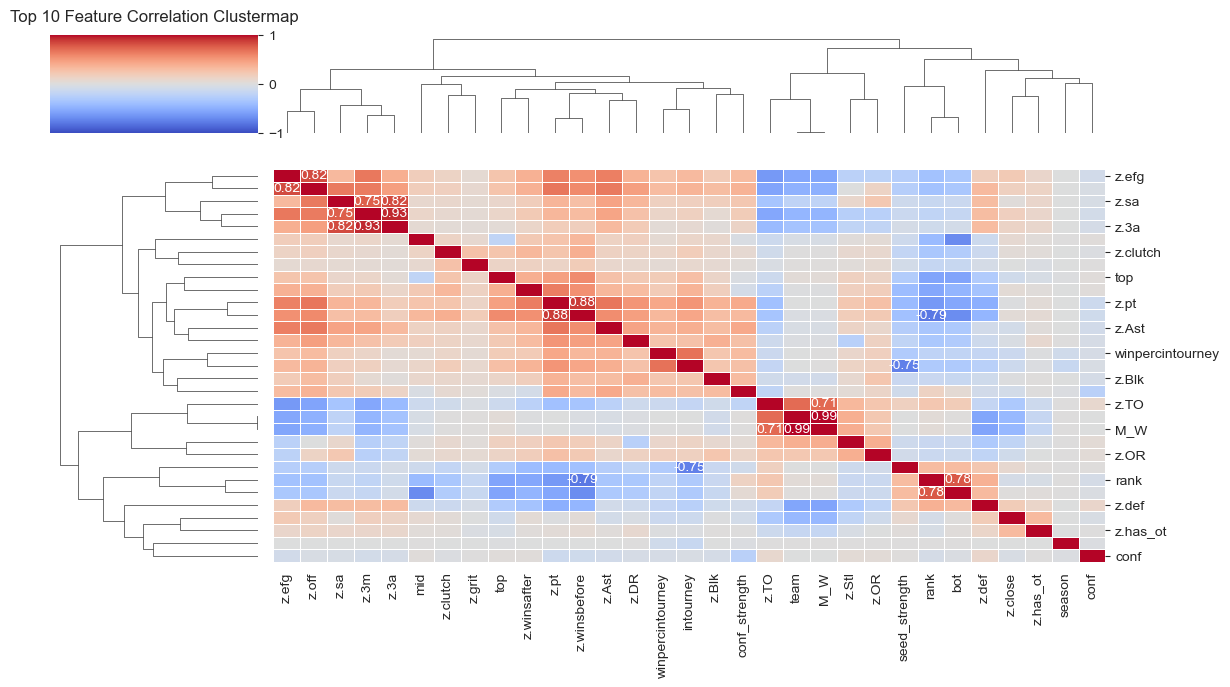

In [28]:
# correlation matrix
corr = df.corr(method='pearson')

# top correlations for annotation
top_n = 20

# Flatten matrix, ignore diagonal
corr_flat = corr.abs().unstack()
corr_flat = corr_flat[corr_flat < 1]

# Identify top N correlations
top_corr_pairs = corr_flat.sort_values(ascending=False).head(top_n).index

# Create annotation matrix
annot = np.full(corr.shape, '', dtype=object)
for i, j in top_corr_pairs:
    annot[corr.columns.get_loc(i), corr.columns.get_loc(j)] = f'{corr.loc[i, j]:.2f}'
    annot[corr.columns.get_loc(j), corr.columns.get_loc(i)] = f'{corr.loc[i, j]:.2f}'

# Plot Clustermap
sns.clustermap(
    corr,
    cmap='coolwarm',
    linewidths=0.5,
    figsize=(12,7),
    annot=annot,
    fmt = '',
    vmin=-1, vmax=1
)

plt.title('Top 10 Feature Correlation Clustermap', y=1.05)
plt.tight_layout()
plt.show()

In [29]:
### Hierarchical clustering

# Compute linkage matrix
linkage = sch.linkage(corr, method='ward')

# Assign cluster labels (e.g., 3 clusters)
cluster_labels = sch.fcluster(linkage, t=3, criterion='maxclust')
cluster_dict = dict(zip(corr.columns, cluster_labels))

In [30]:
### Build network graph
threshold = 0.6 
G = nx.Graph()

# Add nodes with cluster as attribute
for var, cluster in cluster_dict.items():
    G.add_node(var, cluster=cluster)

# Add edges for strong correlations
for i in range(len(corr.columns)):
    for j in range(i+1, len(corr.columns)):
        if abs(corr.iloc[i,j]) >= threshold:
            G.add_edge(corr.columns[i], corr.columns[j], weight=abs(corr.iloc[i,j]))

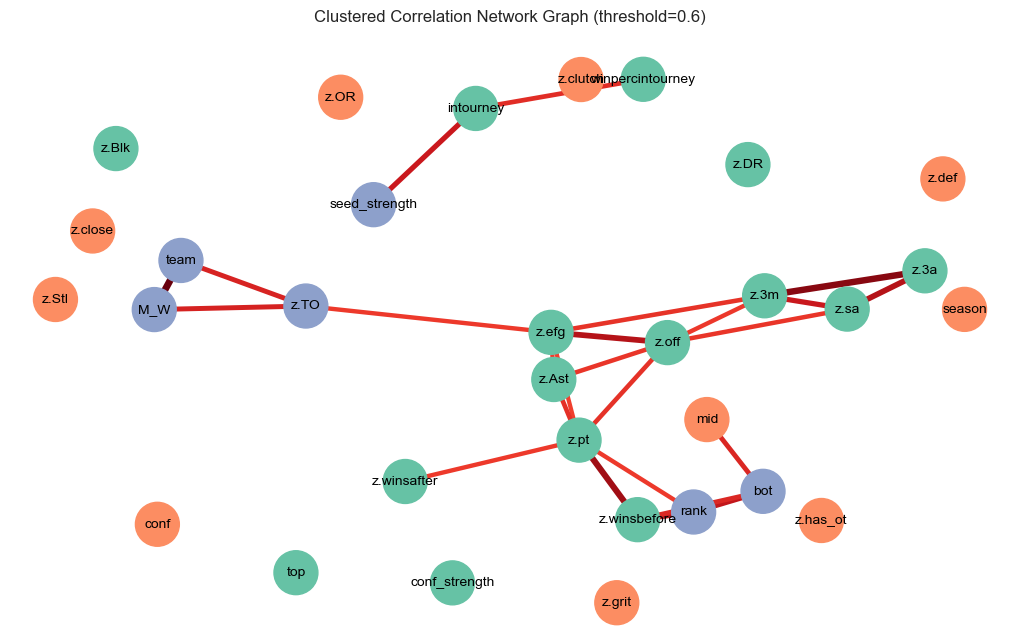

In [31]:
### Draw network graph
plt.figure(figsize=(10,6))
pos = nx.spring_layout(G, k=0.5, seed=42)

# Node colors by cluster
cluster_colors = sns.color_palette("Set2", n_colors=len(set(cluster_labels)))
node_colors = [cluster_colors[cluster_dict[node]-1] for node in G.nodes()]

# Edge widths proportional to correlation strength
edge_weights = [d['weight']*5 for (u,v,d) in G.edges(data=True)]

# Use absolute correlation for edge color
edge_colors = [d['weight'] for (u,v,d) in G.edges(data=True)]

nx.draw(
    G,
    pos,
    with_labels=True,
    node_size=1000,
    node_color=node_colors,
    font_size=10,
    width=edge_weights,
    edge_color=edge_colors,
    edge_cmap=plt.cm.Reds,
    edge_vmin=0, edge_vmax=1
)

plt.title(f'Clustered Correlation Network Graph (threshold={threshold})')
plt.show()

##### Seeing quite a few high correlations, but they intuitively make sense
> ##### point differential is correlated with # of wins before day 100. Teams with higher margins of victory would be expected to have more wins in general
> ##### shots attempted is correlated with 3's attempted and made
> ##### efficient field goal % is correlated with points scored (z.off)
##### Repetitive variables cause instability in a model via multicollinearity. Will be worth doing some sort of feature selection for robustness